
# 🧪 Intro to Machine Learning (Hands-on)

**Audience:** First-year PhD students (no coding experience)  
**Focus:** Data → Scaling → PCA → Clustering  

---

## Learning Goals
- Understand what "features" are
- See why scaling matters
- Visualize high-dimensional data with PCA
- Perform clustering (unsupervised learning)

---


## 🔹 0. Setup

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


## 🔹 1. Load and Explore Data

In [3]:

data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



### 🧠 Exercise 1
- How many samples are there?
- How many features?
- What are the feature names?


In [ ]:
print("Shape of X:", X.shape)
print("Feature names:", X.columns.tolist())




Shape of X: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 🔹 2. Why Scaling Matters

In [6]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



### 🧠 Exercise 2
- Do all features have similar ranges?
- Why might this be a problem?


### ✅ Apply Scaling

In [8]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 🧠 Exercise 3

In [9]:

pd.DataFrame(X_scaled).describe()


,0,1,2,3
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


## 🔹 3. PCA (Dimensionality Reduction)

In [10]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


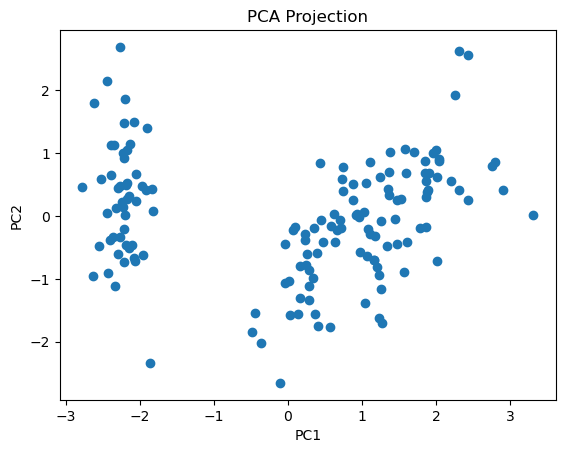

In [11]:

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()



### 🧠 Exercise 4
- Do you see clusters forming?


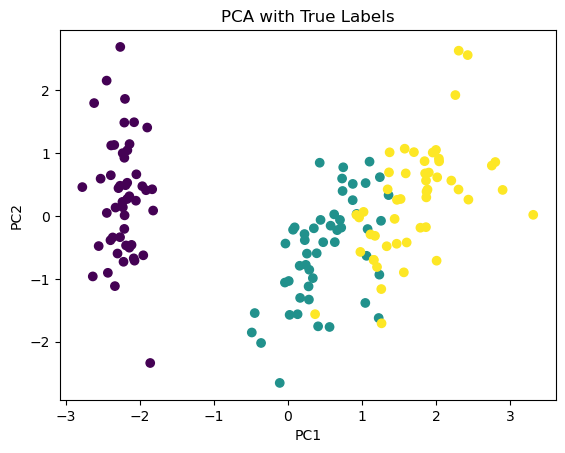

In [12]:

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with True Labels")
plt.show()



### 🧠 Exercise 5
- Does PCA use labels?
- Is this supervised or unsupervised?


## 🔹 4. Variance Explained (Scree Plot)

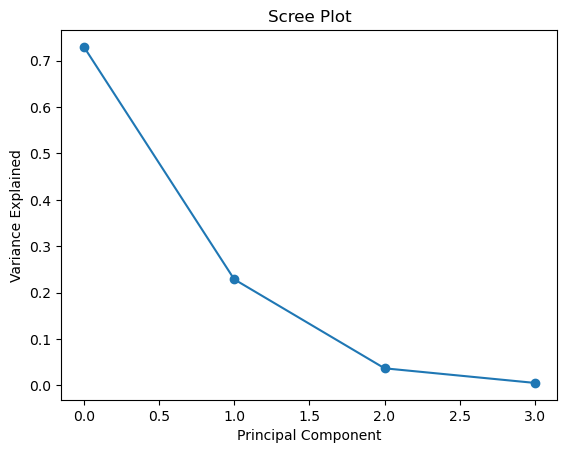

In [13]:

pca_full = PCA()
pca_full.fit(X_scaled)

plt.plot(pca_full.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.show()



### 🧠 Exercise 6
- How many components explain most variance?


## 🔹 5. Clustering (K-Means)

In [14]:

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


c:\Users\kmark\.conda\envs\CM515\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


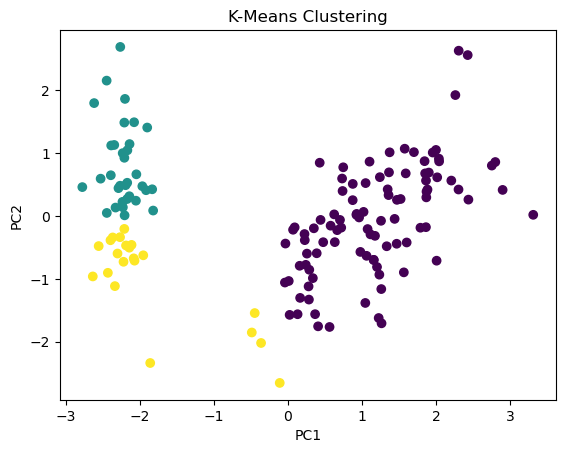

In [15]:

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering")
plt.show()



### 🧠 Exercise 7
- Do clusters match labels?


## 🔹 6. Choosing K

c:\Users\kmark\.conda\envs\CM515\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


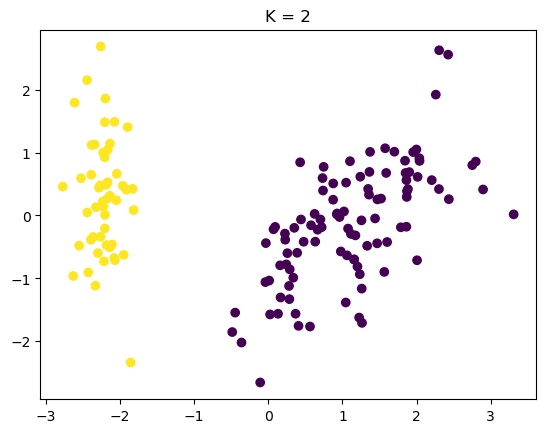

c:\Users\kmark\.conda\envs\CM515\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


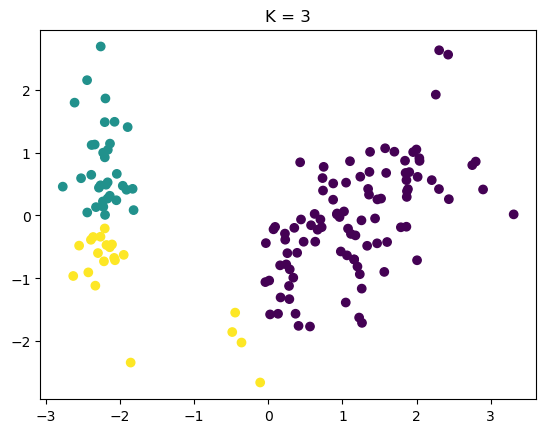

c:\Users\kmark\.conda\envs\CM515\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


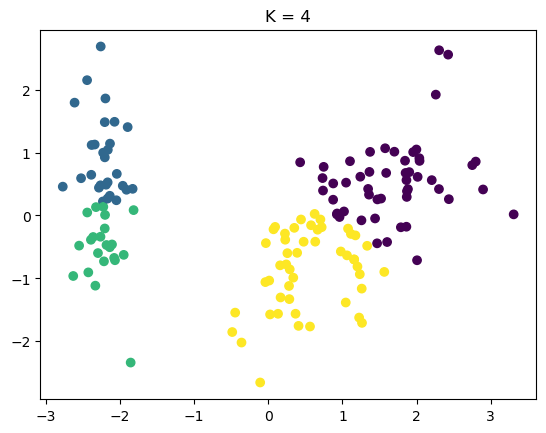

In [16]:

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
    plt.title(f"K = {k}")
    plt.show()



### 🧠 Exercise 8
- What happens when K is too small or large?


## 🔹 7. Bonus: Bad Feature Example

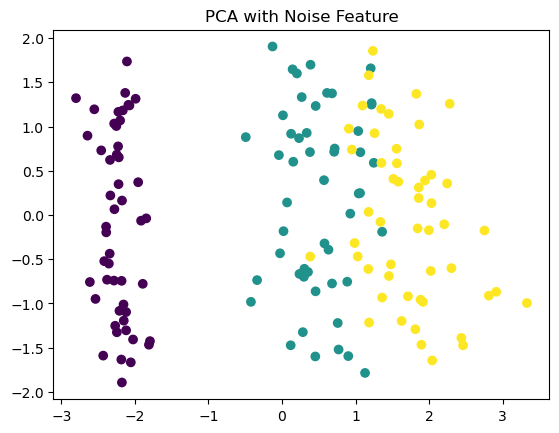

In [17]:

X["random_noise"] = np.random.rand(len(X))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA with Noise Feature")
plt.show()



### 🧠 Exercise 9
- Did noise help or hurt?
- Why is feature selection important?
